In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("claims_train.csv")

In [3]:
def letter_to_index(letter):
    return ord(letter.upper()) - ord('A')
df['Area'] = df['Area'].apply(letter_to_index)

In [4]:
# df['Claim/Exposure'] = df['ClaimNb'] / df['Exposure']

In [5]:
list(df.columns)

['IDpol',
 'ClaimNb',
 'Exposure',
 'Area',
 'VehPower',
 'VehAge',
 'DrivAge',
 'BonusMalus',
 'VehBrand',
 'VehGas',
 'Density',
 'Region']

In [6]:
df['VehIsregular'] = df['VehGas'] == 'Regular'
df = df.drop(columns= 'VehGas')

In [7]:
# df = pd.get_dummies(df) # drop_first=True

In [8]:
df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,Density,Region,VehIsregular
0,2122523.0,0,0.43,3,7,18,36,95,B1,1054,R24,True
1,3173420.0,0,0.10,3,7,17,80,95,B2,598,R25,True
2,1188619.0,0,0.33,4,7,3,36,76,B6,4172,R82,True
3,31400.0,0,0.56,0,5,4,73,52,B13,15,R24,False
4,3138755.0,0,0.27,4,8,0,37,50,B11,3021,R53,False


(array([3.62847e+05, 1.70291e+05, 8.20100e+03, 8.77000e+02, 1.11000e+02,
        2.20000e+01, 8.00000e+00, 6.00000e+00, 1.00000e+01, 3.70000e+01]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

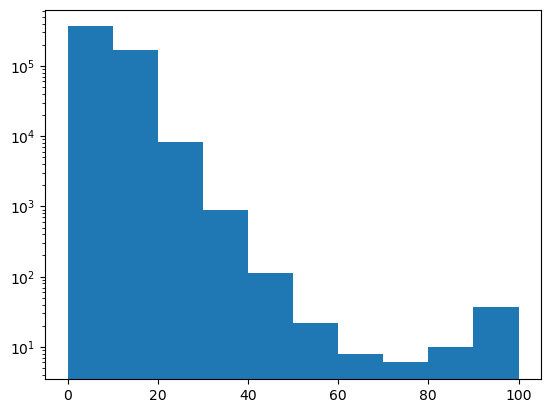

In [9]:
plt.hist(df['VehAge'], log= 'y')

In [10]:
df = df.dropna()

In [11]:
df.shape

(542410, 12)

In [12]:
# plt.close('all')
# features = [
#  'ClaimNb',
#  'Exposure',
#  'Area',
#  'VehPower',
#  'VehAge',
#  'DrivAge',
#  'BonusMalus',
#  'Density']
# n = len(features)

# # Create pairplot using matplotlib
# fig, axes = plt.subplots(n, n, figsize=(12, 12))

# for i in range(n):
#     for j in range(n):
#         ax = axes[i, j]
#         if i == j:
#             # Diagonal: histogram
#             ax.hist(df[features[i]], bins=20, color='gray', edgecolor='black')
#             ax.set_ylabel(features[i])
#         else:
#             # Off-diagonal: scatter plot
#             ax.scatter(df[features[j]], df[features[i]], alpha=0.5)
#         if i == n - 1:
#             ax.set_xlabel(features[j])
#         else:
#             ax.set_xticks([])
#         if j == 0:
#             ax.set_ylabel(features[i])
#         else:
#             ax.set_yticks([])

# plt.tight_layout()
# plt.suptitle("Matplotlib Pairplot Equivalent", y=1.02)
# # plt.savefig("Pairplot.png", dpi=100, bbox_inches='tight')
# plt.show()
# plt.close('all')


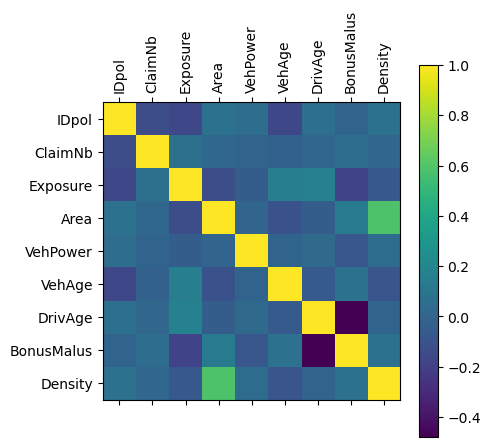

In [13]:
df_numerical = df.drop(columns=['VehBrand', 'Region', 'VehIsregular'])
plt.matshow(df_numerical.corr())
plt.xticks(range(len(df_numerical.columns)), df_numerical.columns, rotation=90)
plt.yticks(range(len(df_numerical.columns)), df_numerical.columns)
plt.colorbar()
plt.show()

(array([5.15199e+05, 2.57180e+04, 0.00000e+00, 1.41600e+03, 0.00000e+00,
        6.70000e+01, 0.00000e+00, 4.00000e+00, 0.00000e+00, 2.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 2.00000e+00]),
 array([ 0.  ,  0.55,  1.1 ,  1.65,  2.2 ,  2.75,  3.3 ,  3.85,  4.4 ,
         4.95,  5.5 ,  6.05,  6.6 ,  7.15,  7.7 ,  8.25,  8.8 ,  9.35,
         9.9 , 10.45, 11.  ]),
 <BarContainer object of 20 artists>)

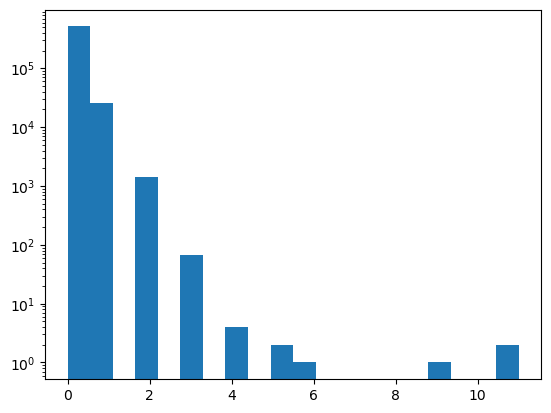

In [14]:
plt.hist(df['ClaimNb'], bins=20, log = 'y')

In [15]:
# # Create one row of subplots
# fig, axes = plt.subplots(len(df_numerical.columns), 1, figsize=(4, 4 * len(df_numerical.columns)))

# # Loop through each column and corresponding subplot
# for ax, column in zip(axes, df_numerical.columns):
#     ax.hist(df_numerical[column], bins=20, color='skyblue', edgecolor='black', log= 'y')
#     ax.set_title(column)

# plt.tight_layout()
# plt.show()


In [16]:
# # Create one row of subplots
# fig, axes = plt.subplots(len(df_numerical.columns), 1, figsize=(4, 4 * len(df_numerical.columns)))

# # Loop through each column and corresponding subplot
# for ax, column in zip(axes, df_numerical.columns):
#     ax.hist(df_numerical[column], bins=20, color='skyblue', edgecolor='black')
#     ax.set_title(column)

# plt.tight_layout()
# plt.show()


In [17]:
from sklearn.preprocessing import StandardScaler



scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numerical)

X_scaled

array([[-0.30499148, -0.22246846, -0.27119315, ..., -0.67229429,
         2.253198  , -0.18715963],
       [ 0.33509395, -0.22246846, -1.17663576, ...,  2.4404532 ,
         2.253198  , -0.30215225],
       [-0.87381825, -0.22246846, -0.5455697 , ..., -0.67229429,
         1.03831038,  0.59912769],
       ...,
       [ 0.27704329, -0.22246846, -0.51813205, ..., -0.95527134,
         2.253198  , -0.3919272 ],
       [-0.98082959, -0.22246846,  0.52449884, ..., -0.46006151,
         0.78254456,  0.37948168],
       [-1.49415594, -0.22246846,  0.16780932, ..., -0.31857299,
         2.95655399, -0.44639739]], shape=(542410, 9))

In [18]:
df_numerical.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'Density'],
      dtype='object')

In [ ]:
features = df_numerical.drop(columns = "ClaimNb")
target = df_numerical["ClaimNb"]

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

